In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
import pandas as pd
from tqdm.notebook import tqdm

# ============================================================
# 1. Magnetic field map
# ============================================================

df = pd.read_csv("field_sweeper_3D.csv")

df = df[['x[m]','y[m]','z[m]','By[T]']]
df['By[T]'] = -0.60*df['By[T]']

### Trick to expand field map in Y by factor 2
#df['y[m]'] = df['y[m]']*2

# Grid (meters)
x_vals = np.sort(df["x[m]"].unique())
y_vals = np.sort(df["y[m]"].unique())
z_vals = np.sort(df["z[m]"].unique())

By_grid = np.zeros((len(x_vals), len(y_vals), len(z_vals)))

# Create index lookup
x_index = {v: i for i, v in enumerate(x_vals)}
y_index = {v: i for i, v in enumerate(y_vals)}
z_index = {v: i for i, v in enumerate(z_vals)}

for _, row in df.iterrows():
    i = x_index[row["x[m]"]]
    j = y_index[row["y[m]"]]
    k = z_index[row["z[m]"]]
    By_grid[i, j, k] = -row["By[T]"]

By_interp = RegularGridInterpolator(
    (x_vals, y_vals, z_vals),
    By_grid,
    bounds_error=False,
    fill_value=0.0
)

In [10]:
# ============================================================
# 2. Particle properties
# ============================================================

Z = 12
A = 37

q = Z * 1.602e-19 # charge (C)
m = A * 1.6605e-27 # mass (kg)      

# Initial conditions
beta = 0.35
Nparticles = 100
v = beta*299792458

# ============================================================
# 3. Time settings
# ============================================================

dt = 1e-11  #Used in field region only
t_max = 2e-8
N = int(t_max / dt)

# ============================================================
# 4. Detector definition
# ============================================================

#DC1
x_det, y_det, z_det = 1.63821, 0.0, 0.561
theta = np.deg2rad(75.0)

# Normal and tangent vectors
n_vec = np.array([-np.sin(theta), 0.0, np.cos(theta)])
t_vec = np.array([np.cos(theta), 0.0, np.sin(theta)])

def plane_function(x, y, z):
    return (x - x_det) * n_vec[0] + (z - z_det) * n_vec[2]

def find_detector_hit(r):
    for i in range(len(r) - 1):
        x1, y1, z1 = r[i, 0], r[i, 1], r[i, 2]
        x2, y2, z2 = r[i + 1, 0], r[i + 1, 1], r[i + 1, 2]

        f1 = plane_function(x1, y1, z1)
        f2 = plane_function(x2, y2, z2)

        if f1 * f2 < 0:
            t = abs(f1) / (abs(f1) + abs(f2))
            x_hit = x1 + t * (x2 - x1)
            y_hit = y1 + t * (y2 - y1)
            z_hit = z1 + t * (z2 - z1)
            return x_hit, y_hit , z_hit

    return None

#DC2
x_det2, y_det2, z_det2 = 3.09386, 0.0, 0.171

def plane_function2(x, y, z):
    return (x - x_det2) * n_vec[0] + (z - z_det2) * n_vec[2]

def find_detector_hit2(r):
    for i in range(len(r) - 1):
        x1, y1, z1 = r[i, 0], r[i, 1], r[i, 2]
        x2, y2, z2 = r[i + 1, 0], r[i + 1, 1], r[i + 1, 2]

        f1 = plane_function2(x1, y1, z1)
        f2 = plane_function2(x2, y2, z2)

        if f1 * f2 < 0:
            t = abs(f1) / (abs(f1) + abs(f2))
            x_hit = x1 + t * (x2 - x1)
            y_hit = y1 + t * (y2 - y1)
            z_hit = z1 + t * (z2 - z1)
            return x_hit, y_hit , z_hit

    return None

# ============================================================
# 5. Run multiple trajectories
# ============================================================

angle_in = 15. #degrees
x0 = -1.25
z0 = 1.0+x0*np.tan(angle_in*np.pi/180.)+0.061077 #0.061077 is offset for theoretical beam trajectory in the field map frame
vx0 = v*np.cos(angle_in*np.pi/180.)
vz0 = v*np.sin(angle_in*np.pi/180.)
v0 = np.array([vx0, 0.0, vz0])     # velocity

v0_mag = v

pos_x = np.random.normal(x0, 0.0005, Nparticles) #Gaussian position spread
pos_y = np.random.normal(0.0, 0.0005, Nparticles) #Gaussian position spread
pos_z = np.random.normal(z0, 0.0005, Nparticles) #Gaussian position spread
angle_x = np.random.normal(angle_in, 0.3, Nparticles) * np.pi / 180  # gaussian angular spread
angle_y = np.random.normal(0.0, 0.3, Nparticles) * np.pi / 180

trajectories = []
hits = []
hits2 = []

for j in range(Nparticles):
    if (100*(j/Nparticles))%10==0:
        print(100*(j/Nparticles))
    # Initial velocity with angular spread in X–Z
    r0 = np.array([pos_x[j], pos_y[j], pos_z[j]])      # start position
    v0 = np.array([
        v0_mag * np.cos(angle_x[j])* np.cos(angle_y[j]),
        v0_mag * np.sin(angle_y[j]),
        v0_mag * np.sin(angle_x[j])* np.cos(angle_y[j])
    ])

    r = np.zeros((N, 3))
    v = np.zeros((N, 3))
    r[0] = r0
    v[0] = v0
    i=0
    # Tracking loop
    #for i in range(N-1):
    while r[i][0]<4.0:
        pos = r[i]

        #Skip region before field
        if i==0:
            dt1 = (-0.8-r[i][0])/v[i][0]
            v[i + 1] = v[i]
            r[i + 1] = r[i] + v[i + 1] * dt1

        #Skip region after the field
        elif r[i][0]>0.8:
            dt2 = (4.5-r[i][0])/v[i][0]
            v[i + 1] = v[i]
            r[i + 1] = r[i] + v[i + 1] * dt2
        
        else:#In the field region
            By_val = By_interp(pos).item()
            B = np.array([0.0, By_val, 0.0])

            a = (q / m) * np.cross(v[i], B)

            v[i + 1] = v[i] + a * dt
            r[i + 1] = r[i] + v[i + 1] * dt

        i+=1
    trajectories.append(r)
    hits.append(find_detector_hit(r))
    hits2.append(find_detector_hit2(r))

0.0
10.0
20.0
30.0
40.0
50.0
60.0
70.0
80.0
90.0


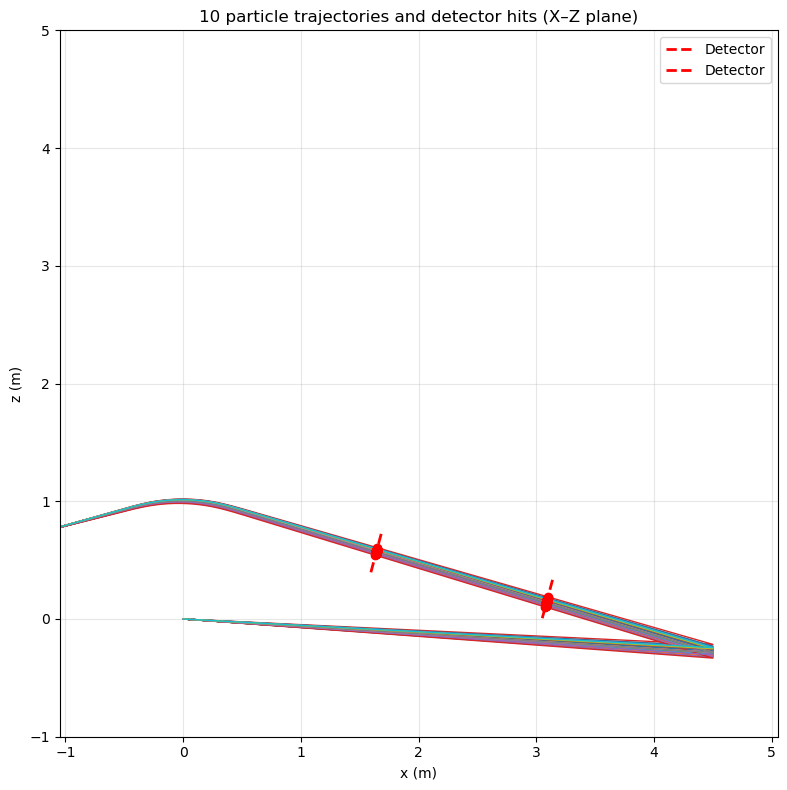

In [11]:
# ============================================================
# 7. Plot trajectory
# ============================================================

plt.figure(figsize=(8, 8))

# Trajectories
for r in trajectories:
    plt.plot(r[:, 0], r[:, 2], lw=1)

# Detector line
#DC1
s = np.linspace(-0.17, 0.17, 100)
plt.plot(
    x_det + s * t_vec[0],
    z_det + s * t_vec[2],
    "r--",
    lw=2,
    label="Detector"
)

#DC2
s = np.linspace(-0.17, 0.17, 200)
plt.plot(
    x_det2 + s * t_vec[0],
    z_det2 + s * t_vec[2],
    "r--",
    lw=2,
    label="Detector"
)

# Hit points
for hit in hits:
    if hit is not None:
        plt.plot(hit[0], hit[2], "ro")

for hit in hits2:
    if hit is not None:
        plt.plot(hit[0], hit[2], "ro")

plt.xlabel("x (m)")
plt.ylabel("z (m)")
plt.title("10 particle trajectories and detector hits (X–Z plane)")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.axis([-1.0,5.0,-1.0,5.0])
plt.tight_layout()
plt.show()

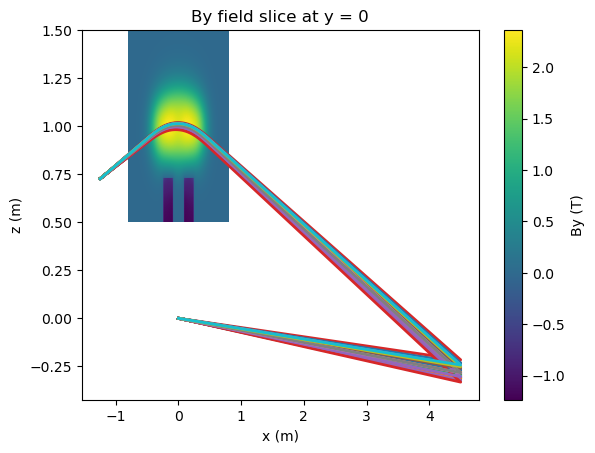

In [12]:
import matplotlib.pyplot as plt

iy = len(y_vals) // 2  # mid-plane slice

plt.imshow(
    -By_grid[:, iy, :].T,
    extent=[x_vals.min(), x_vals.max(), z_vals.min(), z_vals.max()],
    origin="lower",
    aspect="auto"
)

for r in trajectories:
    plt.plot(r[:, 0], r[:, 2], lw=2)
plt.colorbar(label="By (T)")
plt.xlabel("x (m)")
plt.ylabel("z (m)")
plt.title("By field slice at y = 0")
plt.show()

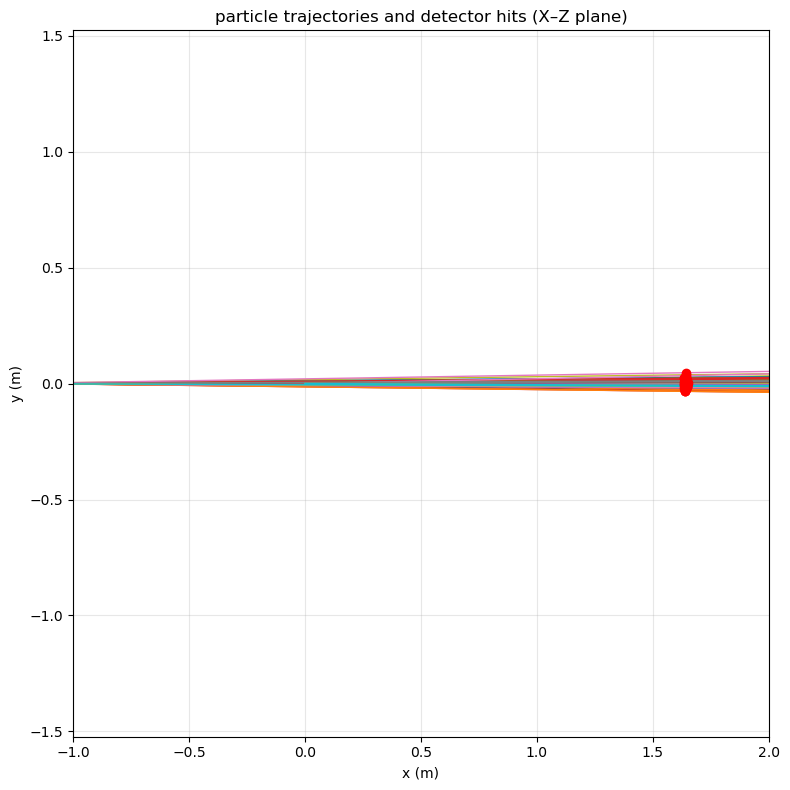

In [13]:
plt.figure(figsize=(8, 8))

# Trajectories
for r in trajectories:
    plt.plot(r[:, 0], r[:, 1], lw=1)

# Hit points
for hit in hits:
    if hit is not None:
        plt.plot(hit[0], hit[1], "ro")

plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("particle trajectories and detector hits (X–Z plane)")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.axis([-1.0,2.0,-0.5,0.5])
plt.tight_layout()
plt.show()

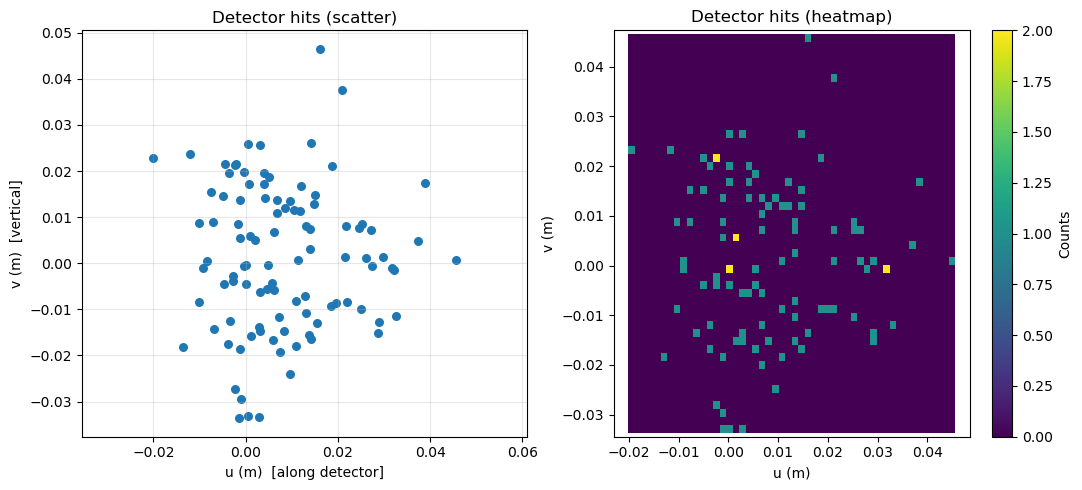

In [14]:
def lab_to_detector_and_plot(hits_lab, x0, y0, z0, theta, bins=40):
    """
    Convert lab-frame hit positions to detector (u, v) coordinates
    and plot the detector hit pattern.

    Parameters
    ----------
    hits_lab : array-like, shape (N, 3)
        Lab-frame hit positions (x, y, z)
    x0, y0, z0 : float
        Detector center in lab frame
    theta : float
        Detector rotation angle in radians (in X–Z plane)
    """

    # Detector basis vectors
    u_hat = np.array([np.cos(theta), 0.0, np.sin(theta)])
    v_hat = np.array([0.0, 1.0, 0.0])

    hits_lab = np.asarray(hits_lab)

    # Shift to detector origin
    dr = hits_lab - np.array([x0, y0, z0])

    # Projection onto detector axes
    u = dr @ u_hat
    v = dr @ v_hat

    fig, axs = plt.subplots(1, 2, figsize=(11, 5))

    # Scatter plot
    axs[0].scatter(u, v, s=30)
    axs[0].set_xlabel("u (m)  [along detector]")
    axs[0].set_ylabel("v (m)  [vertical]")
    axs[0].set_title("Detector hits (scatter)")
    axs[0].axis("equal")
    axs[0].grid(alpha=0.3)

    # Heatmap
    h = axs[1].hist2d(u, v, bins=bins)
    axs[1].set_xlabel("u (m)")
    axs[1].set_ylabel("v (m)")
    axs[1].set_title("Detector hits (heatmap)")
    axs[1].axis("equal")

    plt.colorbar(h[3], ax=axs[1], label="Counts")
    plt.tight_layout()
    plt.show()

    return u, v

x_det, y_det, z_det = 1.63821, 0.0, 0.561
theta = np.deg2rad(75.0)

xdc1, ydc1 = lab_to_detector_and_plot(hits, x_det, y_det, z_det, theta, 50)

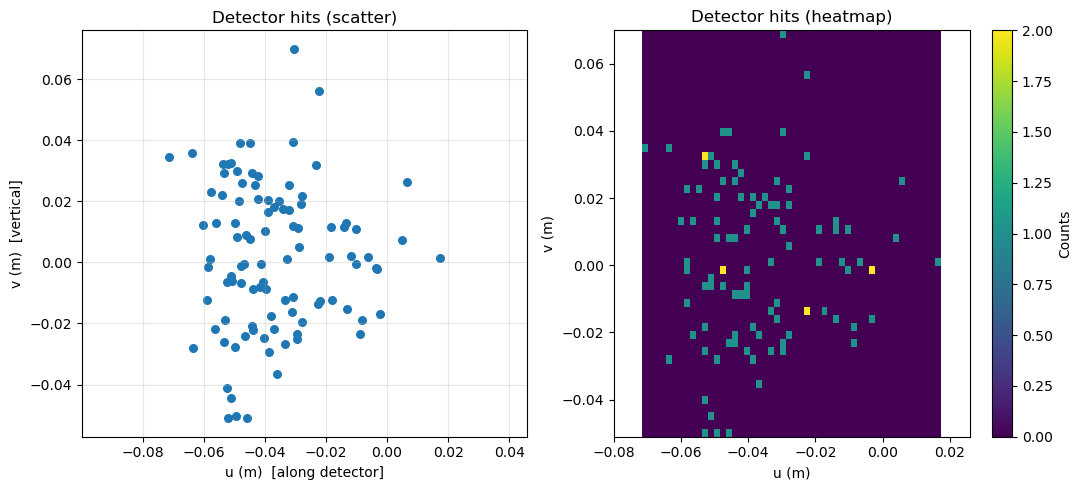

In [15]:
def lab_to_detector_and_plot(hits_lab, x0, y0, z0, theta, bins=40):
    """
    Convert lab-frame hit positions to detector (u, v) coordinates
    and plot the detector hit pattern.

    Parameters
    ----------
    hits_lab : array-like, shape (N, 3)
        Lab-frame hit positions (x, y, z)
    x0, y0, z0 : float
        Detector center in lab frame
    theta : float
        Detector rotation angle in radians (in X–Z plane)
    """

    # Detector basis vectors
    u_hat = np.array([np.cos(theta), 0.0, np.sin(theta)])
    v_hat = np.array([0.0, 1.0, 0.0])

    hits_lab = np.asarray(hits_lab)

    # Shift to detector origin
    dr = hits_lab - np.array([x0, y0, z0])

    # Projection onto detector axes
    u = dr @ u_hat
    v = dr @ v_hat

    fig, axs = plt.subplots(1, 2, figsize=(11, 5))

    # Scatter plot
    axs[0].scatter(u, v, s=30)
    axs[0].set_xlabel("u (m)  [along detector]")
    axs[0].set_ylabel("v (m)  [vertical]")
    axs[0].set_title("Detector hits (scatter)")
    axs[0].axis("equal")
    axs[0].grid(alpha=0.3)

    # Heatmap
    h = axs[1].hist2d(u, v, bins=bins)
    axs[1].set_xlabel("u (m)")
    axs[1].set_ylabel("v (m)")
    axs[1].set_title("Detector hits (heatmap)")
    axs[1].axis("equal")

    plt.colorbar(h[3], ax=axs[1], label="Counts")
    plt.tight_layout()
    plt.show()

    return u, v

x_det, y_det, z_det = 1.63821, 0.0, 0.561
theta = np.deg2rad(75.0)

xdc2, ydc2 = lab_to_detector_and_plot(hits2, x_det2, y_det2, z_det2, theta, 50)